## Time-varying DDM

Autocorrelated fluctuations in $v$, $z$, and $a$

Before we generated the predicted repetition matrices with the posterior means.

Now we sample parameters from the posteriors before simulating data and inspecting the repetition matrices.

For each subject we repeat this 50 times and take the average over these 50 predicted repetition matrix. This averaged predicted repetition matrix is then correlated with the empirical repetition matrix.  


In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from functions import _CustomTwoLevelPrior, _Custom_Simulator, _CustomTwoLevelGenerativeModel
from scipy.stats import beta, gamma, uniform, spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-08-22 11:30:15.273291: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-22 11:30:15.273339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-22 11:30:15.274776: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-22 11:30:15.283128: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-22 11:30:17.035813: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cudnn_version 8
cuda_version 12.2


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

In [4]:
dataset = 'Maniscalco_2017_expt2'

## Set priors

In [5]:
RNG = np.random.default_rng(0)

min_n_trials = 350
max_n_trials = 3250

batch_size = 32

"""
Set parameters for prior distributions 
"""

# uniform for drift rate, starting point, boundary, and non-decision time
v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

# uniform for phi and sigma of AR(1) process
phi_v_bias_lower, phi_v_bias_upper = 0.0, 1.0
phi_z_bias_lower, phi_z_bias_upper = 0.0, 1.0
phi_a_bias_lower, phi_a_bias_upper = 0.0, 1.0

sigma_v_bias_lower, sigma_v_bias_upper = 0.0, 4.0
sigma_z_bias_lower, sigma_z_bias_upper = 0.0, 2.0
sigma_a_bias_lower, sigma_a_bias_upper = 0.0, 2.0

## Prior functions

In [6]:
def sample_shared_parameters():
    """
    Shared parameters are parameters that stay constant over trials within a subject
    and are not related to the AR(1) processes for starting point bias and drift bias
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary)
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter]])
    
    return shared_parameters
    

In [7]:
def sample_hyper_parameters():
    """
    Hyper parameters govern the AR(1) process for starting point bias and drift bias.
    Following hyper parameters are sampled separately for the AR(1) of starting point bias and drift bias:    
    autoregressive coefficient (phi), and sigma.
    
    Note that the fluctuating value for starting point is a actually a bias that we add to 
    the .5 to obtain the starting point (see def _sample_one_diffusion_trial)
    This is easier to implement than a time series that should fluctuate around .5, 
    """
    
    phi_v_bias = np.random.uniform(phi_v_bias_lower, phi_v_bias_upper)
    phi_z_bias = np.random.uniform(phi_z_bias_lower, phi_z_bias_upper)
    phi_a_bias = np.random.uniform(phi_a_bias_lower, phi_a_bias_upper)

    sigma_v_bias = np.random.uniform(sigma_v_bias_lower, sigma_v_bias_upper)
    sigma_z_bias = np.random.uniform(sigma_z_bias_lower, sigma_z_bias_upper)
    sigma_a_bias = np.random.uniform(sigma_a_bias_lower, sigma_a_bias_upper)

    hyper_parameters = np.concatenate([np.r_[phi_v_bias, sigma_v_bias, phi_z_bias, sigma_z_bias, phi_a_bias, sigma_a_bias]])
    
    return hyper_parameters
    

In [8]:
def sample_local_parameters(shared_parameters, hyper_parameters, condition_matrix, num_trials): # hyper_params, local_batchable_context, local_non_batchable_context provided by local_context_generator in TwoLevelPrior
    """
    Local parameters are the trial-to-trial fluctuations in drift bias and starting point bias
    Takes in hyperparameters for AR(1) process
    """
    
    a = shared_parameters[2]
    
    phi_v_bias = hyper_parameters[0]
    sigma_v_bias = hyper_parameters[1]
    
    phi_z_bias = hyper_parameters[2]
    sigma_z_bias = hyper_parameters[3]
    
    phi_a_bias = hyper_parameters[4]
    sigma_a_bias = hyper_parameters[5]
    
    # Initialize first value for drift bias (first column), starting point bias (second column), boundary bias (third column)
    local_parameters = np.zeros((num_trials,3))
    
    local_parameters[0,0] = 0.0
    local_parameters[0,1] = 0.0
    local_parameters[0,2] = 0.0
    
    # Run AR(1) from initial value: x_t = phi * x_t-1 + N(0,sigma)
    for t in range(1, num_trials):
        
        # Drift bias
        local_parameters[t,0] = phi_v_bias * local_parameters[t-1, 0] + np.random.normal(0.0, sigma_v_bias) 

        # Starting point bias
        local_parameters[t,1] = phi_z_bias * local_parameters[t-1, 1] + np.random.normal(0.0, sigma_z_bias) 
        
        # Boundary bias
        local_parameters[t,2] = np.clip(
                                phi_a_bias * local_parameters[t-1, 2] + np.random.normal(0.0, sigma_a_bias),
                                a_min=0.1-a, a_max=1e5 # restrict a_t such that a + a_t is always > 0.1
                                )

    return local_parameters
    

## Sample diffusion trial

In [9]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, num_threads):
    """
    Generates a single response time from a Diffusion Decision process.
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        v_bias = in_v_bias[thread_id]
        z_bias = in_z_bias[thread_id]
        a_bias = in_a_bias[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(20/dt)  # max iterations of the process, 20 seconds
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit     

        # Initialize
        transformed_z = 1/(1+math.exp(-(z+z_bias))) # constrain z + z_bias between 0 and 1 with sigmoid transformation
        evidence = (a+a_bias) * (transformed_z)     # initialize first value (starting point plus bias relative to boundary)
        slope = v+v_bias                            # v and v_bias are both already multiplied with stimulus (effectively making 'slope' a fluctuating drift rate)
        slope_dt = slope*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < (a+a_bias) and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)
    
        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= (a+a_bias):
            resp =  1
        elif evidence <= 0:
            resp = 0
        else:
            resp = -99
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [10]:
@njit(fastmath=True)
def cuda_convert_parameters(parameters, condition_matrix):
    """
    Convert the batched parameters into a vector for each parameter separately
    """
    
    local_parameters = parameters[0]
    shared_parameters = parameters[1]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_v_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a_bias = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        local_parameters_subset = local_parameters[dataset]
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]
            in_v_bias[in_index] = local_parameters_subset[trial,0] * condition_matrix_subset[trial] # by multiplying with stimulus here we effectively create a fluctuating drift rate, instead of drift bias
            in_z_bias[in_index] = local_parameters_subset[trial,1]
            in_a_bias[in_index] = local_parameters_subset[trial,2]

    return in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias


@njit(fastmath=True)
def cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp):
    
    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [11]:
def sample_multiple_diffusion_trials(parameters, condition_matrix): # condition matrix is given by _CustomTwoLevelGenerativeModel as batchable_context (see functions.py line 484)
    """Generates a single simulation from DDM with starting point bias and
    drift bias following an AR(1) model.

    parameters : a tuple consisting of (local_parameters, shared_parameters)
                 as returned by the generator function to the simulator (likelihood) function
                 see source code https://bayesflow.org/_modules/bayesflow/amortizers.html#TwoLevelAmortizedPosterior
    """

    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    # parameters and conditions_matrix should be batched! 
    in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias = cuda_convert_parameters(parameters, condition_matrix)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)

    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, total_threads)

    out = cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp)
    
    return out

## Helper functions

In [12]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std =  uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std =  uniform.stats(ter_lower, ter_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std])
    
    return mean_shared, std_shared



def return_mean_std_hyper_parameters():
    """
    Return the mean and standard deviation of hyperparameters 
    """
    
    phi_v_bias_mean, phi_v_bias_var = uniform.stats(phi_v_bias_lower, phi_v_bias_upper, moments='mv')
    phi_z_bias_mean, phi_z_bias_var = uniform.stats(phi_z_bias_lower, phi_z_bias_upper, moments='mv')
    phi_a_bias_mean, phi_a_bias_var = uniform.stats(phi_a_bias_lower, phi_a_bias_upper, moments='mv')
    
    sigma_v_bias_mean, sigma_v_bias_var = uniform.stats(sigma_v_bias_lower, sigma_v_bias_upper, moments='mv')
    sigma_z_bias_mean, sigma_z_bias_var = uniform.stats(sigma_z_bias_lower, sigma_z_bias_upper, moments='mv')    
    sigma_a_bias_mean, sigma_a_bias_var = uniform.stats(sigma_a_bias_lower, sigma_a_bias_upper, moments='mv')  
    
    # must have same order as output from sample_hyper_parameters()
    mean_hyper = np.array([phi_v_bias_mean, sigma_v_bias_mean, phi_z_bias_mean, sigma_z_bias_mean, phi_a_bias_mean, sigma_a_bias_mean])
    std_hyper = np.sqrt(np.array([phi_v_bias_var, sigma_v_bias_var, phi_z_bias_var, sigma_z_bias_var, phi_a_bias_var, sigma_a_bias_var]))
    
    return mean_hyper, std_hyper

In [13]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials



def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """
    condition_matrix = np.random.uniform(-1, 1, size=num_trials)

    return condition_matrix


## Setting up generator

In [14]:
""" 
6 hyper parameters (phi_v_bias, phi_z_bias, phi_a_bias, sigma_v_bias, sigma_z_bias, sigma_a_bias)
3 local parameters (v_bias, z_bias, a_bias)
4 shared parameters (v, a, z, ter)
"""

experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

prior = _CustomTwoLevelPrior( # custom function that enables local parameters to be constrained by shared parameters (if relu1 for z bias and z is used)
    hyper_prior_fun=sample_hyper_parameters,
    local_prior_fun=sample_local_parameters,
    shared_prior_fun=sample_shared_parameters,
    local_context_generator=experimental_context # provides num_trials and condition_matrix to local_prior_fun (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelPrior)
)

# likelihood only takes in local and shared priors, not the hyper priors (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelGenerativeModel)
# generator outputs both parameters (local and shared priors, not hyper) and batchable context to likelihood 
# _Custom_Simulator makes sure that the batchable context (condition matrix) from prior is used, despite empty context_generator here in likelihood function
likelihood = _Custom_Simulator(
     batch_simulator_fun=sample_multiple_diffusion_trials
)

# _CustomTwoLevelGenerativeModel: outputs both parameters and batchable context (design_matrix) from prior to likelihood as input, see line 484 in functions.py
generator = _CustomTwoLevelGenerativeModel(
     prior=prior,
     simulator=likelihood,
     name="ar1_ddm"
 )


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 82 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the ar1_ddm model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1312, 3)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 1312, 2)


...

INFO:root:Shape of shared_prior_draws batch after 2 pilot simulations: (batch_size = 2, 4)


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:No optional simulation non-batchable context provided.


INFO:root:Could not determine shape of prior batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:Could not determine shape of prior non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes care of that!


## Setting up amortizer

In [15]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""

# Two-level summary network -> reduce 3D into 3D and 2D for local and global amortizer, respectively
summary_network = bf.networks.HierarchicalNetwork(
    [
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    512, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    256, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    128, return_sequences=True
                ),
            ]
        ),
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    64
                )
            ]
        )
    ]
)

# fluctuations for z bias, v bias, a bias
local_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=3, num_coupling_layers=8, coupling_design= 'interleaved'
    ))

# for hyper and shared parameters (first dimensions corresponds to hyperparameters, then shared)
# 6 hyper, 4 shared
global_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=10, num_coupling_layers=12, coupling_design= 'interleaved'
    ))

amortizer = bf.amortizers.TwoLevelAmortizedPosterior(
    local_net,
    global_net,
    summary_network
    )

2026-08-22 11:30:27.322852: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15507 MB memory:  -> device: 0, name: Tesla P100-SXM2-16GB, pci bus id: 0000:62:00.0, compute capability: 6.0


## Checkpoint path

In [16]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [17]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.TwoLevelGenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.TwoLevelAmortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("shared_prior_draws").astype(np.float32)
        hyper_parameters = raw_dict.get("hyper_prior_draws").astype(np.float32)
        local_parameters = raw_dict.get("local_prior_draws").astype(np.float32)


        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["prior_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            mean_hyper, std_hyper = return_mean_std_hyper_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                shared_parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                hyper_parameters=(hyper_parameters-mean_hyper.astype(np.float32))/std_hyper.astype(np.float32),
                local_parameters=local_parameters/5,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                shared_parameters=shared_parameters,
                hyper_parameters=hyper_parameters,
                local_parameters=local_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


In [18]:
raw_sample = generator(batch_size=3)
configured_output = configurator(raw_sample)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Loading in trained model

In [19]:
"""
Connect the networks (summary and inference) with the generative model 
"""


trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=generator,
    configurator=configurator,
    checkpoint_path=checkpoint_path)


INFO:root:Loaded loss history from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training/history_500.pkl.


INFO:root:Networks loaded from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training/ckpt-500


INFO:root:Performing a consistency check with provided components...


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 26 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


2026-08-22 11:30:30.096338: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


INFO:root:Done.


## Fitting empirical data

### 1. Creating correct data structure

In [20]:
# Load in data
data = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Empirical data/{dataset}.csv")

# RT cleaning
data = data[(data['rt'] >= 0.1) & (data['rt'] <= 3)]

# Get number of trials per subject
unique_ids, counts = np.unique(data['subj'], return_counts=True)
print(counts)

num_subjects = len(unique_ids)
max_trials = np.max(counts)

# Change subject numbering starting from 0 uninterupted to num_subjects 
data['subj'] = np.repeat(np.arange(0,num_subjects), counts)

data.to_csv(f"Empirical data/{dataset}_cleaned.csv", index=False)

num_inputs = 3  # rt, response, signed_stim_diff

# Fill with NaNs for padding
df = np.full((num_subjects, max_trials, num_inputs), np.nan)

# Mask indicating valid trials (array of Falses)
trial_mask = np.zeros((num_subjects, max_trials), dtype=bool) 

for subj in range(num_subjects):

    temp = data[data.subj == subj]
    n_trials = len(temp)

    subj_data = np.vstack([temp.rt,
                           temp.resp,
                           temp.evidence]).T

    # Insert trials
    df[subj, :n_trials, :] = subj_data

    # Mark valid trials
    trial_mask[subj, :n_trials] = True

# Log-transform RTs only for valid trials
df[:, :, 0] = np.where(trial_mask,
                       np.log(df[:, :, 0]),
                       np.nan)

# Create context variable (for later)
context = df[:, :, 2]

[509 456 509 509 504 509 508 509 490 508 503 509 499 508 509 508 509 509
 505 509 509 509 507 509 508 497 509 507 509 487 509 505 508 507 500 509
 505 506 509 508 500]


### 2. Estimating parameters

In [21]:
# Fit model to empirical data
num_posterior_samples = 50

num_hyper_parameters = 6
num_shared_parameters = 4
num_local_parameters = 3

estimated_hyper = np.zeros((num_subjects, num_posterior_samples, num_hyper_parameters))
estimated_shared = np.zeros((num_subjects, num_posterior_samples, num_shared_parameters))
estimated_local = np.full((num_subjects, max_trials, num_posterior_samples, num_local_parameters),np.nan)

mean_shared, std_shared = return_mean_std_shared_parameters()
mean_hyper, std_hyper = return_mean_std_hyper_parameters()

for subj in range(num_subjects):

    # Select only valid trials
    valid_idx = trial_mask[subj]
    subj_data = df[subj, valid_idx]

    n_trials = subj_data.shape[0]

    posterior_samples = amortizer.sample(
        {"summary_conditions": subj_data.reshape(1, n_trials, 3)},
        num_posterior_samples)

    # Unstandardize posterior samples
    estimated_hyper[subj] = (posterior_samples["global_samples"][:, 0:6] * std_hyper + mean_hyper)
    estimated_shared[subj] = (posterior_samples["global_samples"][:, 6:11] * std_shared + mean_shared)
    estimated_local[subj, :n_trials] = (posterior_samples["local_samples"] * 5) # Store only valid local trials
    
# Posterior means
estimated_hyper_mean = np.nanmean(estimated_hyper, axis=1)
estimated_shared_mean = np.nanmean(estimated_shared, axis=1)
estimated_local_mean = np.nanmean(estimated_local, axis=2)

# Posterior stds
estimated_hyper_std = np.nanstd(estimated_hyper, axis=1)
estimated_shared_std = np.nanstd(estimated_shared, axis=1)
estimated_local_std = np.nanstd(estimated_local, axis=2)

/tmp/ipykernel_2132536/2589477297.py:35: RuntimeWarning: Mean of empty slice
  estimated_local_mean = np.nanmean(estimated_local, axis=2)
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [22]:
# Posterior variance of Ter is really small compared to other params
np.mean(estimated_shared_std, axis=0)

array([0.26481094, 0.11413272, 0.09331366, 0.00707746])

### 3. Plotting shared parameters

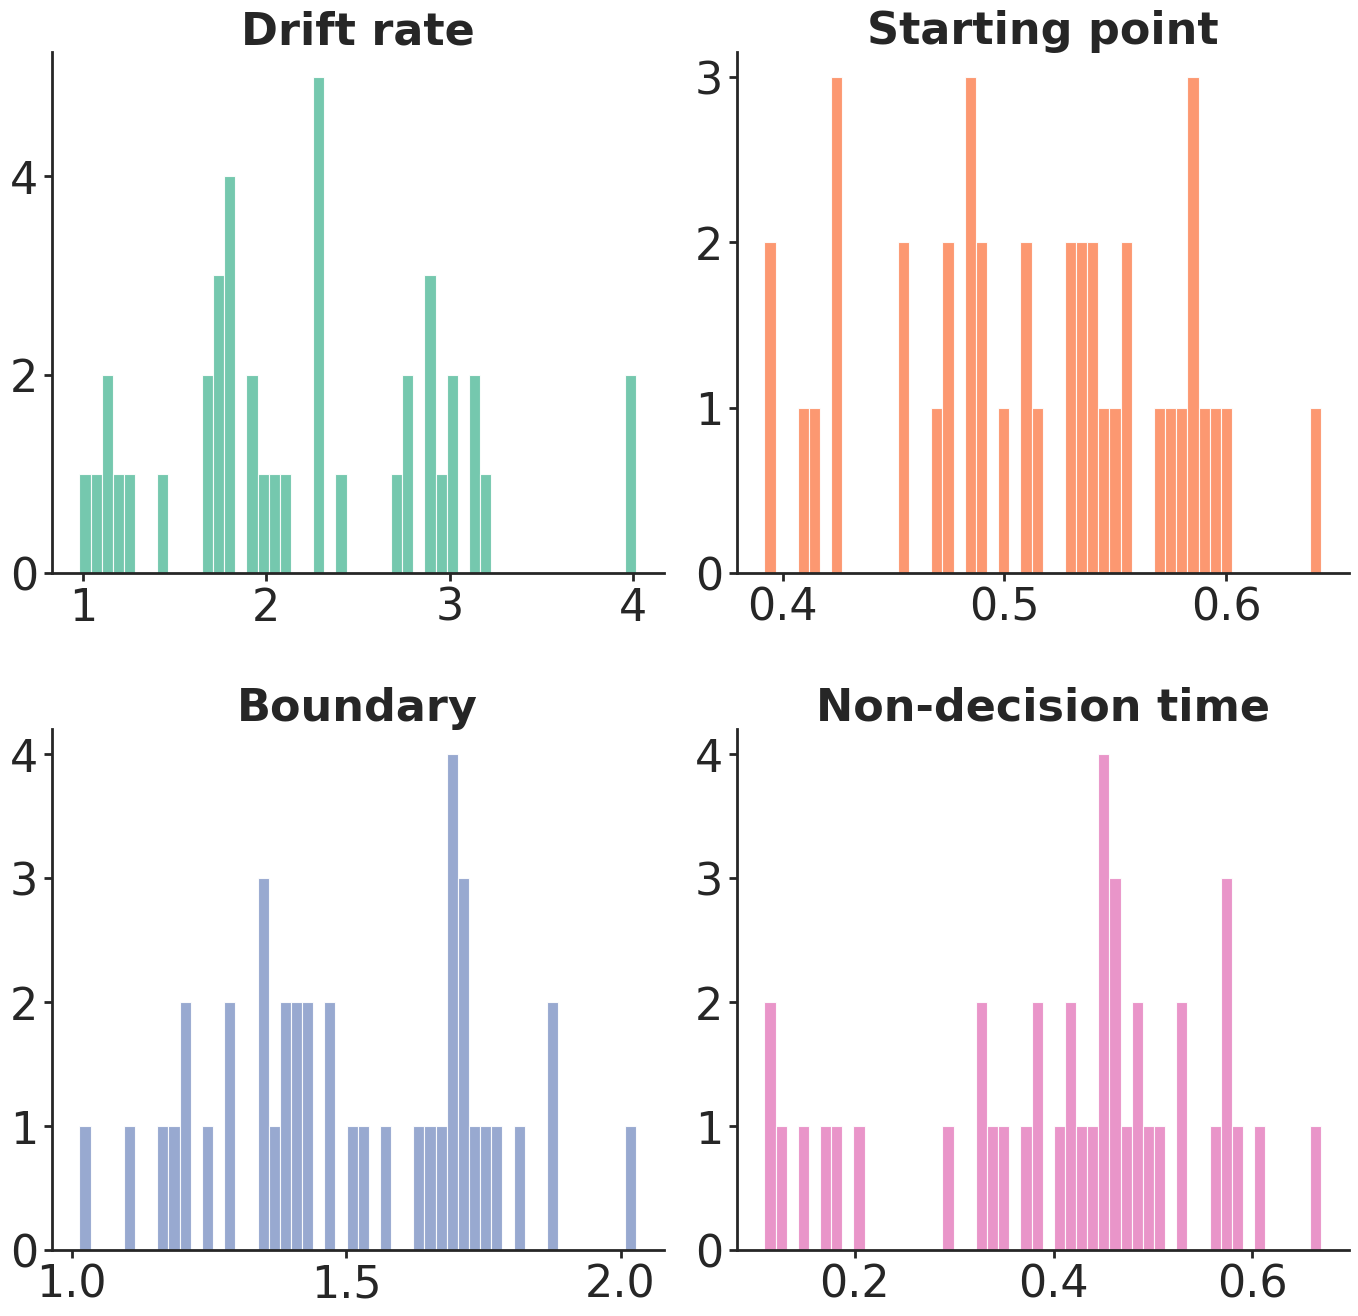

In [23]:
fontsize = 32

sns.set_theme(
    style="ticks",
    context="talk"
)

#shared_param_labels = ["Drift rate $v$", "Starting point $z$", "Boundary $a$", "Non-decision time $T_{er}$"]
shared_param_labels = ["Drift rate", "Starting point", "Boundary", "Non-decision time"]

# Set seaborn style
sns.set(style="ticks", font_scale=1.7)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for i, ax in enumerate(axes.flatten()):
    if i < len(shared_param_labels):
        
        if i == 1:
            values = 1 / (1 + np.exp(-estimated_shared_mean[:, i]))  # sigmoid transform
        else:
            values = estimated_shared_mean[:, i]

        ax.hist(values, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", linewidth=0.8, alpha=0.9)

        #ax.set_xlabel("Value", fontsize=fontsize)
        #ax.set_ylabel("Frequency", fontsize=fontsize)
        ax.set_title(shared_param_labels[i], fontsize=fontsize, fontweight='bold')
        ax.tick_params(labelsize=fontsize)

        # Clean up
        sns.despine(ax=ax)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(2.0)

        ax.tick_params(width=2.0)
    else:
        ax.axis('off')

# Title and layout
#fig.suptitle("Shared Parameters Recovery", fontsize=26, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.3)
plt.savefig(f'Figures/{dataset}_autocorrelated_ddm_shared_params.png', dpi=300)
plt.show()

### 4. Plotting hyperparameters

In [24]:
np.mean(estimated_hyper_mean, axis=0)

array([0.45320573, 1.0515944 , 0.80511446, 0.08930276, 0.85088349,
       0.05373363])

In [25]:
np.mean(estimated_hyper_mean, axis=1)

array([0.53592015, 0.4990452 , 0.59441943, 0.54220042, 0.52266255,
       0.48833529, 0.59040517, 0.63167508, 0.48201432, 0.44568604,
       0.50918068, 0.63674045, 0.56340513, 0.38856431, 0.64992778,
       0.55901643, 0.61959063, 0.43278421, 0.62955727, 0.66095471,
       0.42981584, 0.49029797, 0.60864016, 0.6990887 , 0.47231572,
       0.6586942 , 0.74446215, 0.46585636, 0.41586862, 0.5562442 ,
       0.48483758, 0.5435759 , 0.59308846, 0.64428811, 0.53087234,
       0.66080503, 0.64444557, 0.52645048, 0.44565181, 0.5136939 ,
       0.46512381])

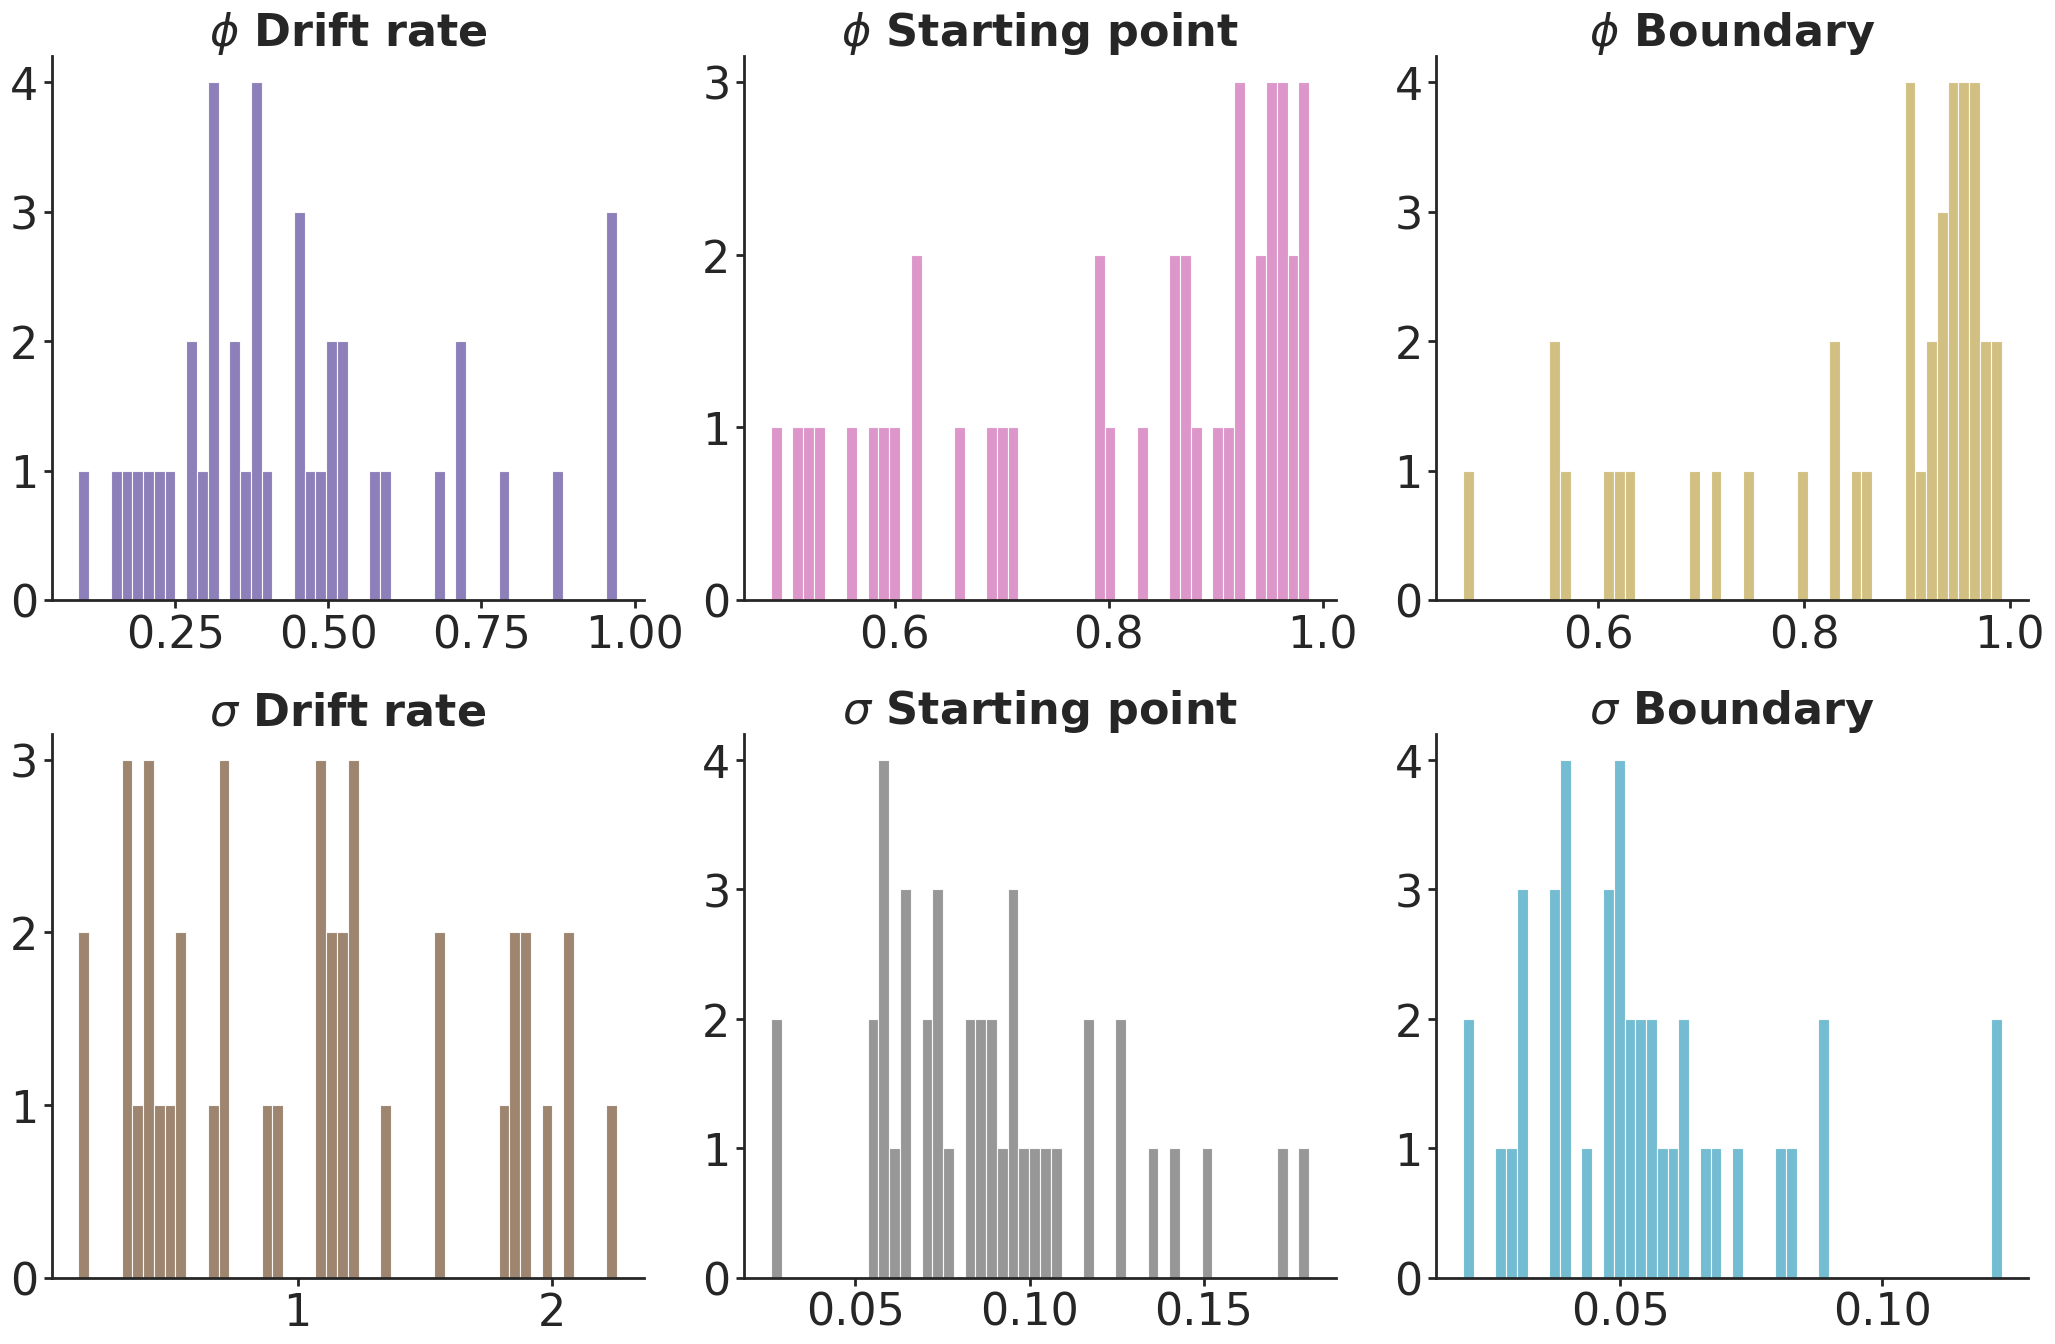

In [26]:
# Saving plots hyper parameters
hyper_param_labels = ["$\phi$ Drift rate","$\sigma$ Drift rate","$\phi$ Starting point","$\sigma$ Starting point","$\phi$ Boundary","$\sigma$ Boundary"]

plot_order = [0, 2, 4, 1, 3, 5] # first all phi, then all sigma

colors = sns.color_palette()
colors = colors[4:10]

fig, axes = plt.subplots(2, 3, figsize=(21, 14))

for ax, i in zip(axes.flatten(), plot_order):
    ax.hist(estimated_hyper_mean[:,i], bins=50, color=colors[i], edgecolor="white", linewidth=0.8, alpha=0.9)
    #ax.set_xlabel("Value", fontsize=fontsize)
    #ax.set_ylabel("Frequency", fontsize=fontsize)
    ax.set_title(hyper_param_labels[i], fontsize=fontsize, fontweight='bold')  
    sns.despine(ax=ax)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.0)

    ax.tick_params(width=2.0, labelsize=fontsize)

#fig.suptitle("Estimated hyper parameters", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(f'Figures/{dataset}_autocorrelated_ddm_empirical_hyper_params.png', dpi=300) 

### 5. Plotting local parameters

In [27]:
# Savings plots of local parameters
sns.set(style="white")
n_subjects = estimated_local_mean.shape[0]

with PdfPages(f"Figures/{dataset}_autocorrelated_ddm_empirical_local_params.pdf") as pdf:
    for subject in range(n_subjects):
        fig, axes = plt.subplots(1, 3, figsize=(10, 5))

        for i, ax in enumerate(axes):
            if i == 0:
                ax.plot(estimated_local_mean[subject, :, i], color=sns.color_palette("Set2")[0], linewidth=2)
                ax.set_ylabel(r"$v$", fontsize=14)
            elif i == 1:
                z = 1 / (1 + np.exp(-(estimated_shared_mean[subject, 1] + estimated_local_mean[subject, :, i])))
                ax.plot(z, color=sns.color_palette("Set2")[1], linewidth=2)
                ax.set_ylabel(r"$z + z_{\mathrm{bias}}$", fontsize=14)
            else:
                a = estimated_shared_mean[subject, 2] + estimated_local_mean[subject, :, i]
                ax.plot(a, color=sns.color_palette("Set2")[2], linewidth=2)
                ax.set_ylabel(r"$a + a_{\mathrm{bias}}$", fontsize=14)

            ax.set_xlabel("Trial", fontsize=14)
            sns.despine(ax=ax)

        fig.suptitle(f"Subject {subject}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        pdf.savefig(fig)
        plt.close(fig)

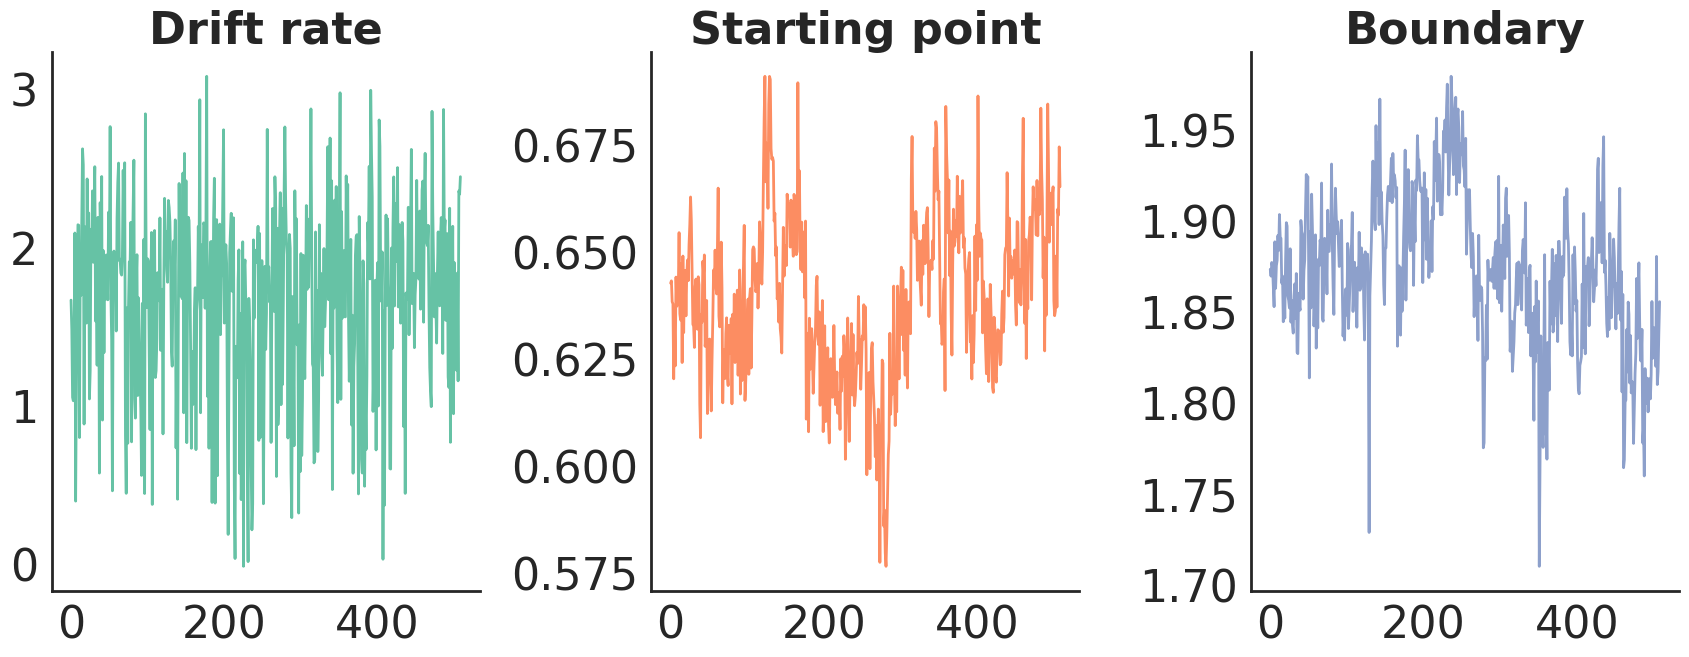

In [28]:
trajectories_labels = ["Drift rate","Starting point","Boundary"]

subject = 0

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for i, ax in enumerate(axes):
    if i == 0:
        ax.plot(estimated_shared_mean[subject, i] + estimated_local_mean[subject, :, i], color=sns.color_palette("Set2")[0], linewidth=2)
        #ax.set_ylabel("Value", fontsize=fontsize)
    elif i == 1:
        z = 1 / (1 + np.exp(-(estimated_shared_mean[subject, 1] + estimated_local_mean[subject, :, i])))
        ax.plot(z, color=sns.color_palette("Set2")[1], linewidth=2)
        
    else:
        a = estimated_shared_mean[subject, 2] + estimated_local_mean[subject, :, i]
        ax.plot(a, color=sns.color_palette("Set2")[2], linewidth=2)

    ax.set_title(trajectories_labels[i], fontsize=fontsize, fontweight='bold')  
    #ax.set_xlabel("Trial", fontsize=fontsize)
    sns.despine(ax=ax)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.0)
    ax.tick_params(width=2.0, labelsize=fontsize)
    
plt.subplots_adjust(wspace=0.4)
plt.savefig(f'Figures/{dataset}_autocorrelated_ddm_example_trajectories_{subject}.png', dpi=300) 

## Predict responses and RTs based on estimated parameters
Data is predicted using parameter values sampled from the posterior.

Based on this predicted data we calculate the CAF and repetition matrix. 

We repeat this procedure 50 times.


In [29]:
num_repetitions = 50

# For conditional accuracy function
cond_acc_subject_over_repetition = np.zeros((num_subjects * 7, num_repetitions)) # 7 quantiles
cond_rt_subject_over_repetition = np.zeros((num_subjects * 7, num_repetitions)) # 7 quantiles

# For repetition matrix
cond_props_subject_over_repetition = np.zeros((num_subjects * 16, num_repetitions)) # 4 x 4 conditions

for repetition in range(num_repetitions):
    
    #print('repetition:', repetition)
    
    # Draw parameter samples from the posterior distributions
    all_hyper_params_sampled = np.zeros((num_subjects, num_hyper_parameters))
    all_shared_params_sampled = np.zeros((num_subjects, num_shared_parameters))
    all_local_params_sampled = np.full((num_subjects, max_trials, num_local_parameters), np.nan)

    for subj in range(num_subjects):
        
        n_trials_subj = trial_mask[subj].sum()
        context_subj = context[subj, :n_trials_subj]
        
        for shared in range(num_shared_parameters): # sample parameter from posterior (second axis are the posterior samples)
            all_shared_params_sampled[subj,shared] = np.random.choice(estimated_shared[subj,:,shared])
        
        for hyper in range(num_hyper_parameters):
            sample = np.random.choice(estimated_hyper[subj, :, hyper])
            if hyper in [1,3,5]: # Apply ReLU to avoid negative samples for sigma
                sample = max(1e-4, sample)
            all_hyper_params_sampled[subj, hyper] = sample
       
        # Resample local trajectories based on new hyperparameter samples
        sampled_local = sample_local_parameters(all_shared_params_sampled[subj, :],
                                                all_hyper_params_sampled[subj, :],
                                                context_subj,
                                                n_trials_subj)
        # Store into padded array
        all_local_params_sampled[subj, :n_trials_subj] = sampled_local
        
        
    # Predicting data based on empirical parameter values
    num_repeat_stimulus_sequence = 20

    predicted_rt = []
    predicted_resp = []
    predicted_context = []
    predicted_subj = []
    
    for subj in range(num_subjects):

        n_trials_subj = trial_mask[subj].sum()
        context_subj = context[subj, :n_trials_subj]
        local_subj = all_local_params_sampled[subj, :n_trials_subj]

        # Repeat context (stimulus on each trial) and shuffle
        context_subj_repeated = np.random.permutation(np.tile(context_subj, num_repeat_stimulus_sequence))
        
        # Repeat local parameters
        local_subj_repeated = np.tile(local_subj, (num_repeat_stimulus_sequence, 1))
        
        # Predict data
        parameters = (
            local_subj_repeated[None, :, :], # add None for account for batching structure required in sample_multiple_diffusion_trials
            all_shared_params_sampled[subj][None, :]
        )

        simulated = sample_multiple_diffusion_trials(
            parameters,
            context_subj_repeated[None, :]
        )

        predicted_rt.append(simulated[0, :, 0])
        predicted_resp.append(simulated[0, :, 1])
        predicted_context.append(context_subj_repeated)
        predicted_subj.append(np.full(len(context_subj_repeated), subj))
    
    predicted_rt = np.concatenate(predicted_rt)
    predicted_resp = np.concatenate(predicted_resp)
    predicted_context = np.concatenate(predicted_context)
    predicted_subj = np.concatenate(predicted_subj)
    predicted_accuracy = (
        ((predicted_resp == 1) & (np.sign(predicted_context) == 1)) |
        ((predicted_resp == 0) & (np.sign(predicted_context) == -1))
    ).astype(int)

    df_predicted = pd.DataFrame({
        "subj": predicted_subj,
        "rt": predicted_rt,
        "resp": predicted_resp,
        "stimulus": predicted_context,
        "accuracy": predicted_accuracy
    })
    
    
    
    # 1. Determine fast and slow errors: median split on error trials
    
    median_rt_per_subj_predicted = (
        df_predicted.loc[df_predicted["accuracy"] == 0]
        .groupby("subj", as_index=False)["rt"]
        .median()
        .rename(columns={"rt": "median_rt_incorrect"}))

    df_predicted = df_predicted.merge(median_rt_per_subj_predicted, on="subj", how="left")
    df_predicted["slow_response"] = df_predicted["rt"] > df_predicted["median_rt_incorrect"]
    
    df_predicted["condition"] = np.select([(df_predicted["resp"] == 1) & (~df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 1) & (df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 0) & (~df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 0) & (df_predicted["slow_response"]),],
                                          
                                           ["fast_right",
                                            "slow_right",
                                            "fast_left",
                                            "slow_left",],
                                          
                                            default="no_response")
    
    
    # 2. Create lagged variables
    
    df_predicted["prev_condition"] = (
    df_predicted.groupby("subj")["condition"].shift(1))

    df_predicted["prev_accuracy"] = (
        df_predicted.groupby("subj")["accuracy"].shift(1))
    
    
    # 3. Conditional accuracy plot
    # 3.1 Conditional accuracy plot: create RT quantiles
    
    df_predicted["quantiles_rt"] = (df_predicted
                                .groupby("subj")["rt"]
                                .transform(lambda x: pd.qcut(x.rank(method="first"), q=7, labels=range(1, 8))))
    
    # 3.2 Conditional accuracy plot: calculate mean accuracy and RT per subject per quantile and save
    
    mean_acc_subj = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
    mean_rt_subj = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()
    
    cond_acc_subject_over_repetition[:,repetition] = mean_acc_subj['mean']
    cond_rt_subject_over_repetition[:,repetition] = mean_rt_subj['mean']
    
    
    # 4. Repetition matrix
    # 4.1 Repetition matrix: create subset with two subsequent error trials only
    
    data_incorrect_predicted = df_predicted[(df_predicted["accuracy"] == 0) & (df_predicted["prev_accuracy"] == 0)]
    
    # 4.2 Repetition matrix: calculate proportions
    
    cols = ["subj", "condition", "prev_condition"]

    subj = np.arange(0, num_subjects)
    condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])
    prev_condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])

    levels = [subj, condition, prev_condition]

    full_index = pd.MultiIndex.from_product(levels, names=cols)

    freq_incorrect_predicted = (
        data_incorrect_predicted
        .groupby(cols)
        .size()
        .reindex(full_index, fill_value=0)
        .reset_index(name="count"))
    
    cond_props_subject_over_repetition[:,repetition] = freq_incorrect_predicted.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum()).fillna(0)
    

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


...

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Preparing empirical data for CAF and repetition matrix

In [30]:
# 1. Define different trial types: median split on only error trials
median_rt_per_subj = (
    data.loc[data["accuracy"] == 0]
    .groupby("subj", as_index=False)["rt"]
    .median()
    .rename(columns={"rt": "median_rt_incorrect"}))

data = data.merge(median_rt_per_subj, on="subj", how="left")
data["slow_response"] = data["rt"] > data["median_rt_incorrect"]

data["condition"] = np.select([(data["resp"] == 1) & (~data["slow_response"]),
                                       (data["resp"] == 1) & (data["slow_response"]),
                                       (data["resp"] == 0) & (~data["slow_response"]),
                                       (data["resp"] == 0) & (data["slow_response"]),],
                                      
                                       ["fast_right",
                                        "slow_right",
                                        "fast_left",
                                        "slow_left",],
                                      
                                        default="no_response")

# 2. Create lagged variables
data["prev_condition"] = (data.groupby("subj")["condition"].shift(1))
data["prev_accuracy"] = (data.groupby("subj")["accuracy"].shift(1))

## Comparing empirical and predicted CAF

### Empirical CAF

In [31]:
# Create RT quantiles
data["quantiles_rt"] = (data.groupby("subj")["rt"]
                            .transform(lambda x: pd.qcut(x.rank(method="first"), q=7, labels=range(1, 8))))

# Calculate mean accuracy and RT per subject per quantile
cond_acc_subject = data.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
cond_rt_subject = data.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()

cond_acc_subject.to_csv(f"Data/{dataset}_autocorrelated_ddm_empirical_caf_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
cond_acc = cond_acc_subject.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()

# Calculate the mean RT and standard error over all subjects to use as labels in the plot
labels_average_rt = cond_rt_subject.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
cond_acc['quantiles_rt_mean_rt'] = labels_average_rt['mean']

### Predicted CAF

In [32]:
# Calculate the mean per subject per quantile over all repetitions
cond_acc_subject_predicted = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean"]).reset_index() # use this dataframe as placeholder and replace mean
cond_acc_subject_predicted['mean'] = np.mean(cond_acc_subject_over_repetition, axis=1)

cond_rt_subject_predicted = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean"]).reset_index() # use this dataframe as placeholder and replace mean
cond_rt_subject_predicted['mean'] = np.mean(cond_rt_subject_over_repetition, axis=1)

cond_acc_subject_predicted.to_csv(f"Data/{dataset}_autocorrelated_ddm_predicted_caf_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
cond_acc_predicted = cond_acc_subject_predicted.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()

# Calculate the mean RT and standard error over all subjects to use as labels in the plot
labels_average_rt_predicted = cond_rt_subject_predicted.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
cond_acc_predicted['quantiles_rt_mean_rt'] = labels_average_rt_predicted['mean']

### Plotting CAF

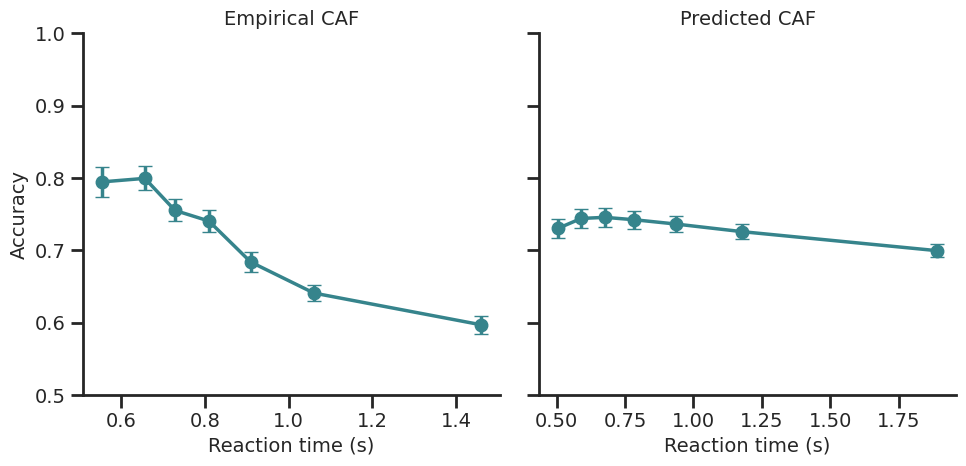

In [33]:
sns.set_theme(
    style="ticks",
    context="talk"
)

fontsize = 14
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Empirical CAF (left)
axes[0].errorbar(
    x=cond_acc["quantiles_rt_mean_rt"],
    y=cond_acc["mean"],
    yerr=cond_acc["std"] / np.sqrt(len(np.unique(data["subj"]))),
    fmt="o-",
    linewidth=2.5,
    capsize=5,
    color="#36848C"
)

axes[0].set_title("Empirical CAF", fontsize=fontsize)
axes[0].set_xlabel("Reaction time (s)", fontsize=fontsize)
axes[0].set_ylabel("Accuracy", fontsize=fontsize)
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(labelsize=fontsize, width=2.0)


# Predicted CAF (right)
axes[1].errorbar(
    x=cond_acc_predicted["quantiles_rt_mean_rt"],
    y=cond_acc_predicted["mean"],
    yerr=cond_acc_predicted["std"] / np.sqrt(len(np.unique(df_predicted["subj"]))),
    fmt="o-",
    linewidth=2.5,
    capsize=5,
    color="#36848C"
)

axes[1].set_title("Predicted CAF", fontsize=fontsize)
axes[1].set_xlabel("Reaction time (s)", fontsize=fontsize)
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(labelsize=fontsize, width=2.0)

# Styling
for ax in axes:
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.0)
    sns.despine(ax=ax)

plt.tight_layout()

fig.savefig(
    f"Figures/{dataset}_autocorrelated_ddm_caf_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

## Comparing empirical and predicted repetition matrix

### Empirical repetition matrix

In [34]:
# Create subset with two subsequent error trials only and calculate proportions
data_incorrect = data[(data["accuracy"] == 0) & (data["prev_accuracy"] == 0)]

cols = ["subj", "condition", "prev_condition"]

subj = np.arange(0, num_subjects)
condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])
prev_condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])

levels = [subj, condition, prev_condition]

full_index = pd.MultiIndex.from_product(levels, names=cols)

freq_incorrect = (
    data_incorrect
    .groupby(cols)
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="count"))

cond_prop_table_subject = freq_incorrect
cond_prop_table_subject["cond_prop"] = cond_prop_table_subject.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum()).fillna(0)

cond_prop_table_subject.to_csv(f"Data/{dataset}_autocorrelated_ddm_empirical_repetition_matrix_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
mean_sd_subjects = (
    cond_prop_table_subject.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

### Predicted repetition matrix

In [35]:
# Calculate the mean per subject per quantile over all repetitions
averaged_cond_props_subject_over_repetition = np.mean(cond_props_subject_over_repetition, axis=1)

# Use freq_incorrect for structure and replace cond_prop
cond_prop_table_subject_predicted = freq_incorrect_predicted
cond_prop_table_subject_predicted['cond_prop'] = averaged_cond_props_subject_over_repetition
cond_prop_table_subject_predicted = cond_prop_table_subject_predicted.drop(columns=["count"]) # remove count (are frequencies from only the last iteration)

cond_prop_table_subject_predicted.to_csv(f"Data/{dataset}_autocorrelated_ddm_predicted_repetition_matrix_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
mean_sd_subjects_predicted = (
    cond_prop_table_subject_predicted.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

### Plotting

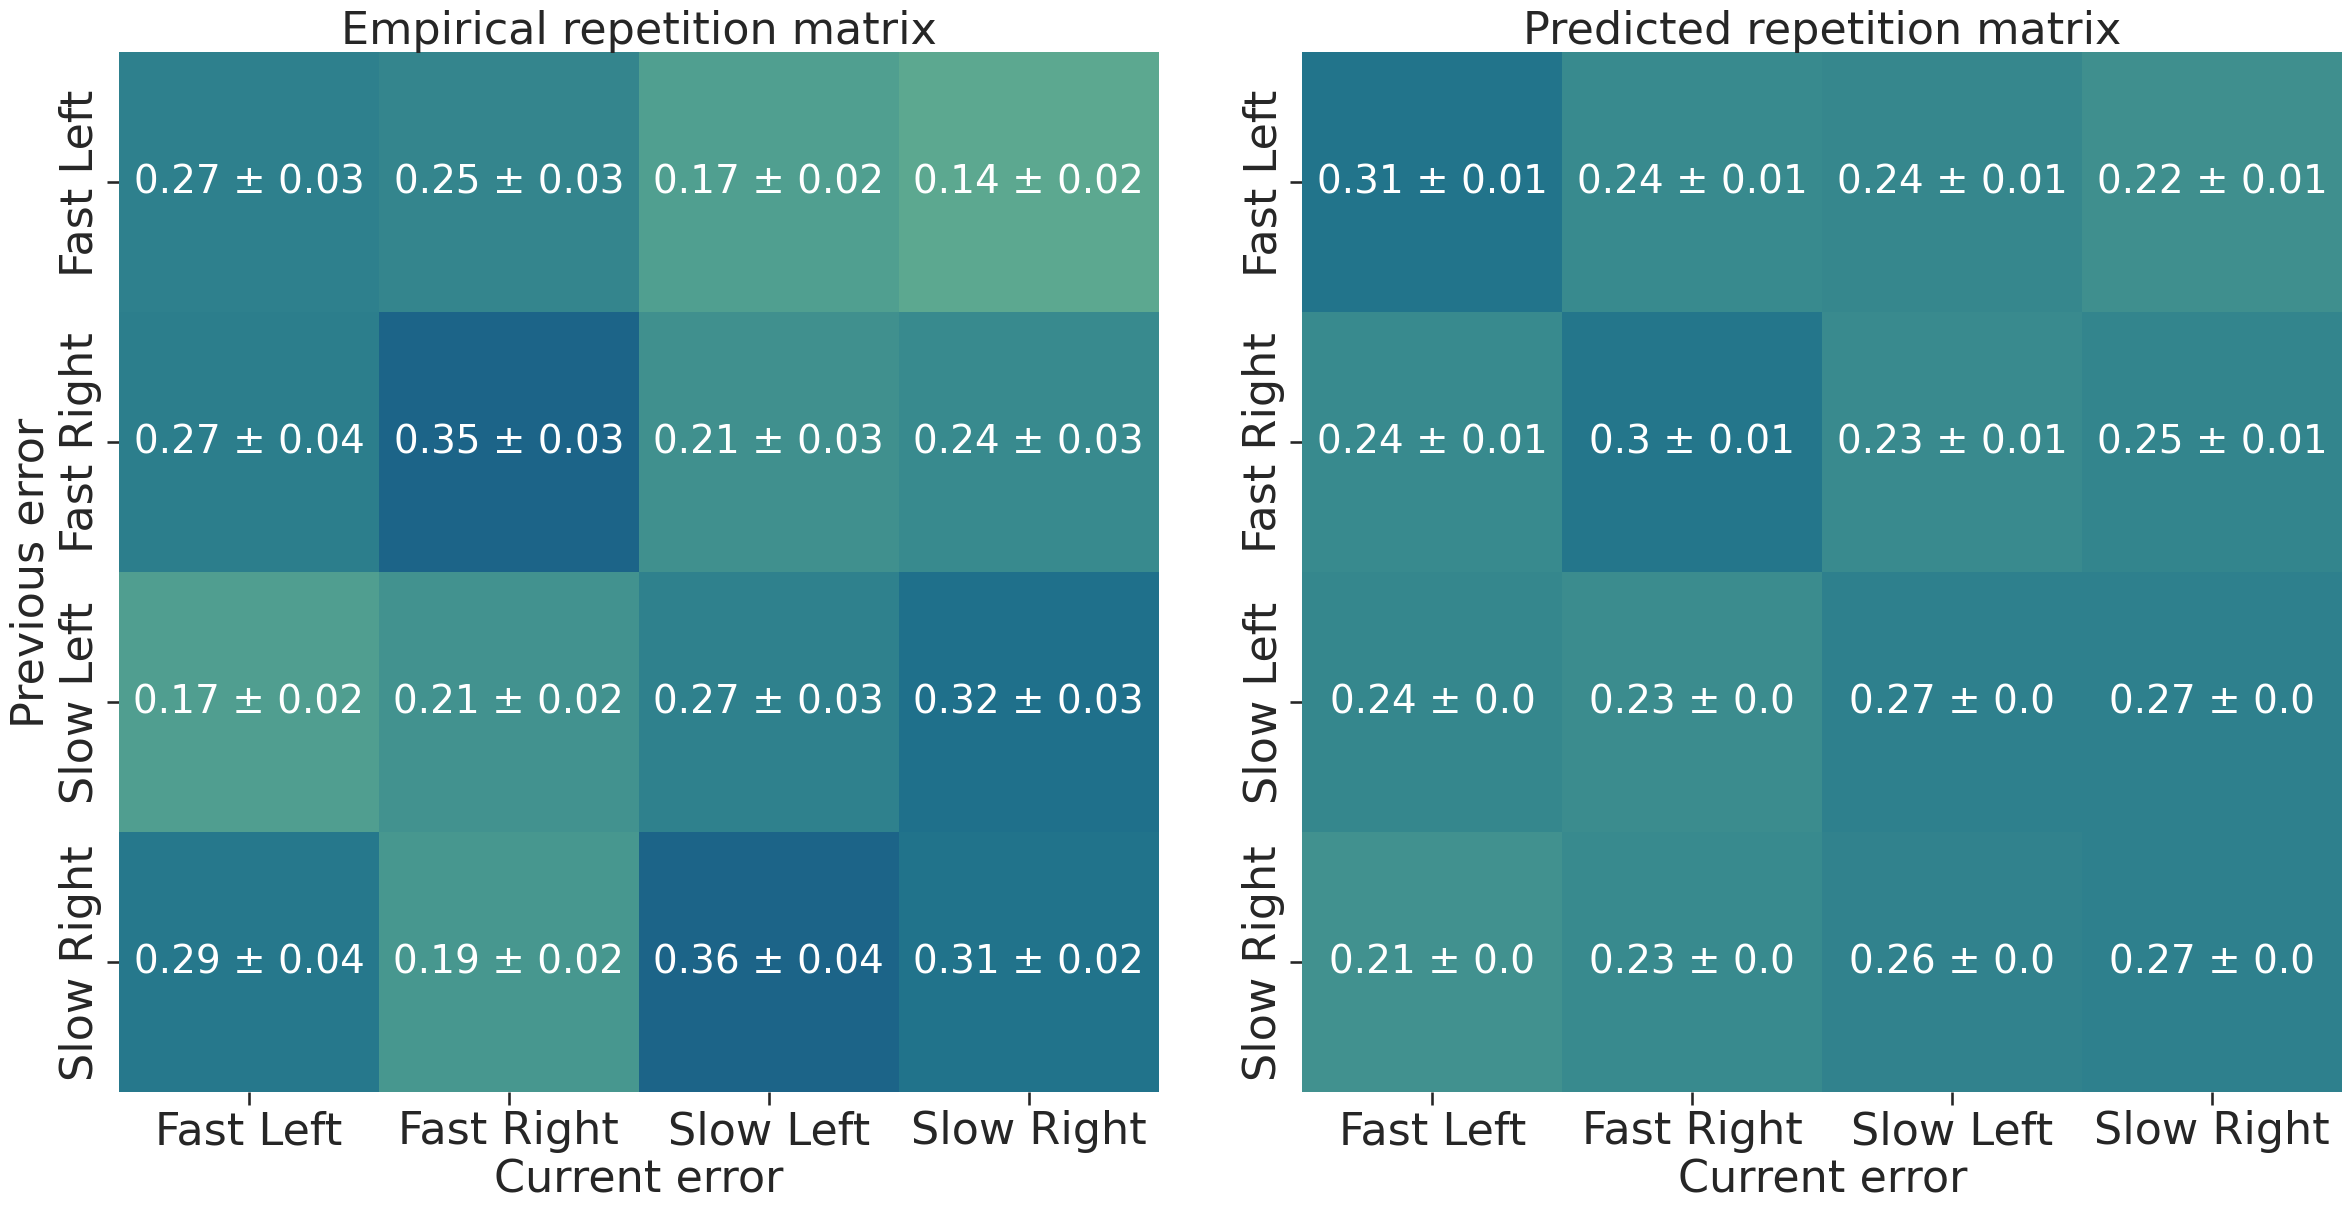

In [36]:
fontsize_heatmap = 32

# Empirical matrices
prop_table_mean = mean_sd_subjects.pivot(
    index="prev_condition",
    columns="condition",
    values="mean"
)

prop_table_std = mean_sd_subjects.pivot(
    index="prev_condition",
    columns="condition",
    values="std"
)

annot = (
    prop_table_mean.round(2).astype(str)
    + " ± "
    + (
        prop_table_std
        / np.sqrt(len(np.unique(data_incorrect["subj"])))
    ).round(2).astype(str)
)

# Predicted matrices
prop_table_mean_predicted = mean_sd_subjects_predicted.pivot(
    index="prev_condition",
    columns="condition",
    values="mean"
)

prop_table_std_predicted = mean_sd_subjects_predicted.pivot(
    index="prev_condition",
    columns="condition",
    values="std"
)

annot_predicted = (
    prop_table_mean_predicted.round(2).astype(str)
    + " ± "
    + (
        prop_table_std_predicted
        / np.sqrt(len(np.unique(data_incorrect_predicted["subj"])))
    ).round(2).astype(str)
)

condition_labels = [
    "Fast Left",
    "Fast Right",
    "Slow Left",
    "Slow Right"
]

# Create side-by-side plots
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 12),
    constrained_layout=True
)

# -------------------------
# Empirical
# -------------------------
sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin=0.0,
    vmax=0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Empirical repetition matrix",
    fontsize=fontsize_heatmap
)
axes[0].set_xlabel(
    "Current error",
    fontsize=fontsize_heatmap
)
axes[0].set_ylabel(
    "Previous error",
    fontsize=fontsize_heatmap
)

axes[0].tick_params(axis="x", labelsize=fontsize_heatmap)
axes[0].tick_params(axis="y", labelsize=fontsize_heatmap)

for text in axes[0].texts:
    text.set_fontsize(28)

# -------------------------
# Predicted
# -------------------------
sns.heatmap(
    prop_table_mean_predicted,
    annot=annot_predicted,
    fmt="",
    cmap="crest",
    vmin=0.0,
    vmax=0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "Predicted repetition matrix",
    fontsize=fontsize_heatmap
)
axes[1].set_xlabel(
    "Current error",
    fontsize=fontsize_heatmap
)
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=fontsize_heatmap)
axes[1].tick_params(axis="y", labelsize=fontsize_heatmap)

for text in axes[1].texts:
    text.set_fontsize(28)

fig.savefig(
    f"Figures/{dataset}_autocorrelated_ddm_repetition_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)